#  Notebook 1 — Dataset Exploration & Preprocessing
## KIIT-MiTA: High-Resolution Drone Imagery for Military Object Detection

**CSE 445 — Computer Vision**

| | |
|---|---|
| **Group Number** | `02` |
| **Instructor** | Dr. Mohammad Rifat Ahmmad Rashid, Associate Professor, Dept. of CSE, EWU |

| Name | ID |
|---|---|
| MD SHAFIN AHAMED SIAM | 2023-1-60-007 |
| ALBIN ISRAT SIDDIQUE | 2023-1-60-212 |
| Md. Ariful Islam Opi | 2023-1-60-141 |
| Nasrullah Kaisher Sijan | 2023-1-60-204 |

| Property | Value |
|---|---|
| **Dataset** | KIIT-MiTA (Military Target Detection) |
| **Source** | https://data.mendeley.com/datasets/drjmrf5kk5/1 |
| **Annotation Format** | YOLO v5/v8 (normalized `class cx cy w h`) |
| **Total Images** | 1,700 |
| **Classes** | 7 (Artilary, Missile, Radar, M. Rocket Launcher, Soldier, Tank, Vehicle) |

**Citation:**
> S. Chakrabarty *et al.*, "Drones in Defense: Real-Time Vision-Based Military Target Surveillance and Tracking," *2025 3rd International Conference on ISACC*, Silchar, India, 2025, pp. 508–513, doi: 10.1109/ISACC65211.2025.10969335

---
This notebook covers **Tasks 4.1–4.4** of the assignment:
1. Dataset loading & integrity check
2. Exploratory Data Analysis (EDA)
3. Train/Validation/Test splitting with data leakage prevention
4. Data augmentation pipeline design with justifications
5. Input pipeline verification (before/after visualization)

---
## 0. Configuration & Setup
All dataset paths, class names, image dimensions, and split ratios are centralised in this CONFIG cell. **Change only this cell to reconfigure the entire pipeline.**

In [1]:

import os, pathlib, yaml

# 1. Dynamic Dataset Root Discovery
#    Automatically finds the dataset by searching for the YAML
#    config file under /kaggle/input/. No hardcoded paths needed.

def discover_dataset_root(search_base="/kaggle/input"):
    """Dynamically locate the dataset root by finding its YAML config."""
    search = pathlib.Path(search_base)
    if not search.exists():
        # Fallback for local development
        search = pathlib.Path(".")
    for yml_path in search.rglob("*.yml"):
        try:
            with open(yml_path) as f:
                cfg = yaml.safe_load(f)
            if isinstance(cfg, dict) and "names" in cfg and "nc" in cfg:
                return yml_path.parent, yml_path
        except Exception:
            continue
    for yml_path in search.rglob("*.yaml"):
        try:
            with open(yml_path) as f:
                cfg = yaml.safe_load(f)
            if isinstance(cfg, dict) and "names" in cfg and "nc" in cfg:
                return yml_path.parent, yml_path
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not find a YOLO dataset YAML config under {search_base}. "
        "Please set DATASET_ROOT manually in this cell."
    )

DATASET_ROOT, YAML_PATH = discover_dataset_root()

# 2. Parse Class Names from YAML
with open(YAML_PATH) as f:
    _yaml_cfg = yaml.safe_load(f)

CLASS_NAMES = _yaml_cfg["names"]       # Preserves original dataset spelling
NUM_CLASSES = _yaml_cfg["nc"]          # 7
CLASS_ID2NAME = {i: n for i, n in enumerate(CLASS_NAMES)}

# 3. Annotation Format
ANNOTATION_FORMAT = "yolo"             # class_id cx cy w h (normalised)

# 4. Image Target Size
IMG_SIZE = 640                         # Standard YOLO input resolution

# 5. Split Ratios
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6, "Ratios must sum to 1"

# 6. Original Split Paths (auto-discovered)
ORIG_SPLITS = {}
for split_name in ["train", "valid", "val", "test"]:
    candidate = DATASET_ROOT / split_name
    if candidate.exists():
        key = "valid" if split_name == "val" else split_name
        ORIG_SPLITS[key] = candidate

# 7. Output Directory for Re-split Dataset
RESPLIT_ROOT = pathlib.Path("/kaggle/working/dataset-resplit")

# 8. Near-Duplicate Detection Threshold
PHASH_THRESHOLD = 10  # Hamming distance ≤ this → near-duplicate

# 9. Random Seed
SEED = 42

# 10. Print Configuration Summary
print("=" * 60)
print("CONFIGURATION SUMMARY")
print("=" * 60)
print(f"  Dataset root    : {DATASET_ROOT.resolve()}")
print(f"  YAML config     : {YAML_PATH.name}")
print(f"  Classes ({NUM_CLASSES})     : {CLASS_NAMES}")
print(f"  Annotation fmt  : {ANNOTATION_FORMAT}")
print(f"  Image size      : {IMG_SIZE}×{IMG_SIZE}")
print(f"  Split ratios    : {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}")
print(f"  Resplit output  : {RESPLIT_ROOT}")
print(f"  pHash threshold : {PHASH_THRESHOLD}")
print(f"  Random seed     : {SEED}")
print(f"  Detected splits : {list(ORIG_SPLITS.keys())}")
print("=" * 60)

CONFIGURATION SUMMARY
  Dataset root    : /kaggle/input/datasets/arifulislamopi/kiit-mita/KIIT-MiTA
  YAML config     : KIIT-MiTA.yml
  Classes (7)     : ['Artilary', 'Missile', 'Radar', 'M. Rocket Launcher', 'Soldier', 'Tank', 'Vehicle']
  Annotation fmt  : yolo
  Image size      : 640×640
  Split ratios    : 0.8/0.1/0.1
  Resplit output  : /kaggle/working/dataset-resplit
  pHash threshold : 10
  Random seed     : 42
  Detected splits : ['train', 'valid', 'test']


In [2]:
# IMPORTS
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
import hashlib
import shutil
import random
from collections import Counter, defaultdict
from pathlib import Path
import cv2
import albumentations as A
from IPython.display import display

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

# Plotting defaults
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.facecolor'] = 'white'
sns.set_theme(style='whitegrid', palette='muted')

# Reproducibility
np.random.seed(SEED)
random.seed(SEED)

print(" All imports successful.")
print(f"   NumPy       : {np.__version__}")
print(f"   Pandas      : {pd.__version__}")
print(f"   OpenCV      : {cv2.__version__}")
print(f"   Albumentations : {A.__version__}")

 All imports successful.
   NumPy       : 2.0.2
   Pandas      : 2.3.3
   OpenCV      : 4.13.0
   Albumentations : 2.0.8


---
## 1. Dataset Loading & Integrity Check
Verify file counts, detect missing/corrupt files, and confirm format consistency before any analysis. This ensures we are working with a clean, complete dataset.

In [3]:
# DATASET INTEGRITY CHECK
def integrity_check(dataset_root, splits):
    """
    Comprehensive integrity check:
    - File counts per split
    - Missing labels (images without corresponding label files)
    - Orphan labels (labels without corresponding images)
    - Corrupt image detection (PIL verify)
    - Format consistency (extensions)
    """
    report = []
    all_image_exts = set()
    all_label_exts = set()
    corrupt_images = []
    missing_labels = []
    orphan_labels = []

    for split_name, split_path in splits.items():
        img_dir = split_path / "images"
        lbl_dir = split_path / "labels"

        images = sorted(img_dir.glob("*")) if img_dir.exists() else []
        labels = sorted(lbl_dir.glob("*")) if lbl_dir.exists() else []

        img_stems = {p.stem for p in images}
        lbl_stems = {p.stem for p in labels}

        n_img = len(images)
        n_lbl = len(labels)

        img_exts = {p.suffix.lower() for p in images}
        lbl_exts = {p.suffix.lower() for p in labels}
        all_image_exts |= img_exts
        all_label_exts |= lbl_exts

        split_missing = img_stems - lbl_stems
        missing_labels.extend([(split_name, s) for s in split_missing])

        split_orphan = lbl_stems - img_stems
        orphan_labels.extend([(split_name, s) for s in split_orphan])

        for ip in tqdm(images, desc=f'Verifying {split_name}', leave=False):
            try:
                with Image.open(ip) as im:
                    im.verify()
            except Exception as e:
                corrupt_images.append((split_name, ip.name, str(e)))

        report.append({
            "Split": split_name,
            "Images": n_img,
            "Labels": n_lbl,
            "Img Extensions": ", ".join(img_exts) if img_exts else "—",
            "Lbl Extensions": ", ".join(lbl_exts) if lbl_exts else "—",
            "Missing Labels": len(split_missing),
            "Orphan Labels": len(split_orphan),
        })

    df_report = pd.DataFrame(report)
    return df_report, corrupt_images, missing_labels, orphan_labels, all_image_exts, all_label_exts

# Run integrity check
df_integrity, corrupt, missing, orphans, img_exts, lbl_exts = integrity_check(DATASET_ROOT, ORIG_SPLITS)

print("=" * 60)
print("DATASET INTEGRITY REPORT")
print("=" * 60)
display(df_integrity)

print(f"\nImage formats found : {img_exts}")
print(f"Label formats found : {lbl_exts}")
print(f"Total images        : {df_integrity['Images'].sum()}")
print(f"Total labels        : {df_integrity['Labels'].sum()}")
print(f"Corrupt images      : {len(corrupt)}")
print(f"Missing labels      : {len(missing)}")
print(f"Orphan labels       : {len(orphans)}")

if corrupt:
    print("\n CORRUPT FILES:")
    for c in corrupt:
        print(f"  [{c[0]}] {c[1]}: {c[2]}")
else:
    print("\n No corrupt images detected.")

if missing:
    print(f"\n {len(missing)} images without labels (first 10):")
    for m in missing[:10]:
        print(f"  [{m[0]}] {m[1]}")
else:
    print(" Every image has a corresponding label file.")

if orphans:
    print(f"\n {len(orphans)} orphan label files (first 10):")
    for o in orphans[:10]:
        print(f"  [{o[0]}] {o[1]}")
else:
    print(" No orphan label files.")

Verifying train:   0%|          | 0/1360 [00:00<?, ?it/s]

Verifying valid:   0%|          | 0/170 [00:00<?, ?it/s]

Verifying test:   0%|          | 0/170 [00:00<?, ?it/s]

DATASET INTEGRITY REPORT


,Split,Images,Labels,Img Extensions,Lbl Extensions,Missing Labels,Orphan Labels
0,train,1360,1360,.jpeg,.txt,0,0
1,valid,170,170,.jpeg,.txt,0,0
2,test,170,170,.jpeg,.txt,0,0



Image formats found : {'.jpeg'}
Label formats found : {'.txt'}
Total images        : 1700
Total labels        : 1700
Corrupt images      : 0
Missing labels      : 0
Orphan labels       : 0

 No corrupt images detected.
 Every image has a corresponding label file.
 No orphan label files.


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Parse All Annotations
Load every YOLO label file into a structured DataFrame for analysis.

In [4]:
# PARSE ALL ANNOTATIONS
def parse_yolo_labels(dataset_root, splits, class_names):
    """
    Parse all YOLO label files into two DataFrames:
    - df_boxes:  One row per bounding box annotation
    - df_images: One row per image (with dimensions, aspect ratio, file size)
    """
    records = []
    img_info = []

    for split_name, split_path in splits.items():
        img_dir = split_path / "images"
        lbl_dir = split_path / "labels"

        if not img_dir.exists():
            print(f" Image directory not found: {img_dir.resolve()}")
            continue

        for img_path in tqdm(sorted(img_dir.glob("*")), desc=f'Parsing {split_name}', leave=False):
            stem = img_path.stem
            try:
                with Image.open(img_path) as im:
                    iw, ih = im.size
            except Exception:
                continue

            file_size_kb = img_path.stat().st_size / 1024

            img_info.append({
                "split": split_name,
                "image_stem": stem,
                "img_width": iw,
                "img_height": ih,
                "aspect_ratio": round(iw / ih, 3),
                "file_ext": img_path.suffix.lower(),
                "file_size_kb": round(file_size_kb, 1),
            })

            lbl_path = lbl_dir / f"{stem}.txt"
            if not lbl_path.exists():
                continue

            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cid = int(parts[0])
                    cx, cy, w, h = map(float, parts[1:5])
                    abs_w = w * iw
                    abs_h = h * ih

                    records.append({
                        "split": split_name,
                        "image_stem": stem,
                        "class_id": cid,
                        "class_name": class_names[cid] if cid < len(class_names) else f"UNK_{cid}",
                        "cx": cx, "cy": cy, "w": w, "h": h,
                        "img_width": iw, "img_height": ih,
                        "abs_cx": cx * iw, "abs_cy": cy * ih,
                        "abs_w": abs_w, "abs_h": abs_h,
                        "abs_area": abs_w * abs_h,
                    })

    df_boxes = pd.DataFrame(records)
    df_images = pd.DataFrame(img_info)
    return df_boxes, df_images

df_boxes, df_images = parse_yolo_labels(DATASET_ROOT, ORIG_SPLITS, CLASS_NAMES)

print(f"Total images parsed : {len(df_images)}")
print(f"Total annotations   : {len(df_boxes)}")
mean_boxes = len(df_boxes) / len(df_images) if len(df_images) > 0 else 0.0
print(f"Avg boxes per image : {mean_boxes:.2f}")

print(f"\nPer-split image counts:")
display(df_images.groupby('split').size().rename('count').to_frame())

Parsing train:   0%|          | 0/1360 [00:00<?, ?it/s]

Parsing valid:   0%|          | 0/170 [00:00<?, ?it/s]

Parsing test:   0%|          | 0/170 [00:00<?, ?it/s]

Total images parsed : 1700
Total annotations   : 4586
Avg boxes per image : 2.70

Per-split image counts:


,count
split,
test,170
train,1360
valid,170


### 2.2 Class Distribution
Instance count per class across the entire dataset. Flag any imbalance.

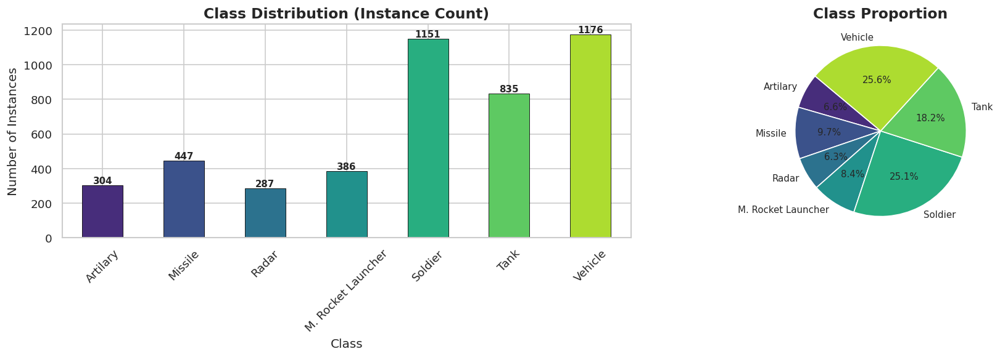


=== Per-Split Class Counts ===


class_name,Artilary,M. Rocket Launcher,Missile,Radar,Soldier,Tank,Vehicle
split,,,,,,,
test,40,45,36,34,120,58,86
train,238,303,367,223,923,683,974
valid,26,38,44,30,108,94,116



Imbalance ratio (max/min): 4.10x
  SIGNIFICANT CLASS IMBALANCE DETECTED.
   → Minority classes:  ['Artilary', 'Radar', 'M. Rocket Launcher']
   → Majority classes:  ['Missile', 'Soldier', 'Tank', 'Vehicle']


In [5]:
# CLASS DISTRIBUTION
class_counts = df_boxes['class_name'].value_counts().reindex(CLASS_NAMES)
imbalance_ratio = class_counts.max() / class_counts.min()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = sns.color_palette('viridis', n_colors=NUM_CLASSES)
class_counts.plot.bar(ax=axes[0], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution (Instance Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Instances')
axes[0].tick_params(axis='x', rotation=45)
for i, (cls, cnt) in enumerate(class_counts.items()):
    axes[0].text(i, cnt + 10, str(cnt), ha='center', fontsize=9, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 9})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Per-split class counts
print("\n=== Per-Split Class Counts ===")
split_class = df_boxes.groupby(['split', 'class_name']).size().unstack(fill_value=0)
display(split_class)

# Imbalance flag
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}x")
if imbalance_ratio > 3:
    print("  SIGNIFICANT CLASS IMBALANCE DETECTED.")
    print("   → Minority classes: ", [c for c, v in class_counts.items() if v < class_counts.median()])
    print("   → Majority classes: ", [c for c, v in class_counts.items() if v >= class_counts.median()])
else:
    print(" Class distribution is reasonably balanced.")

### 2.3 Image Properties
Resolution distribution, aspect-ratio spread, file-size distribution, and file-format breakdown.

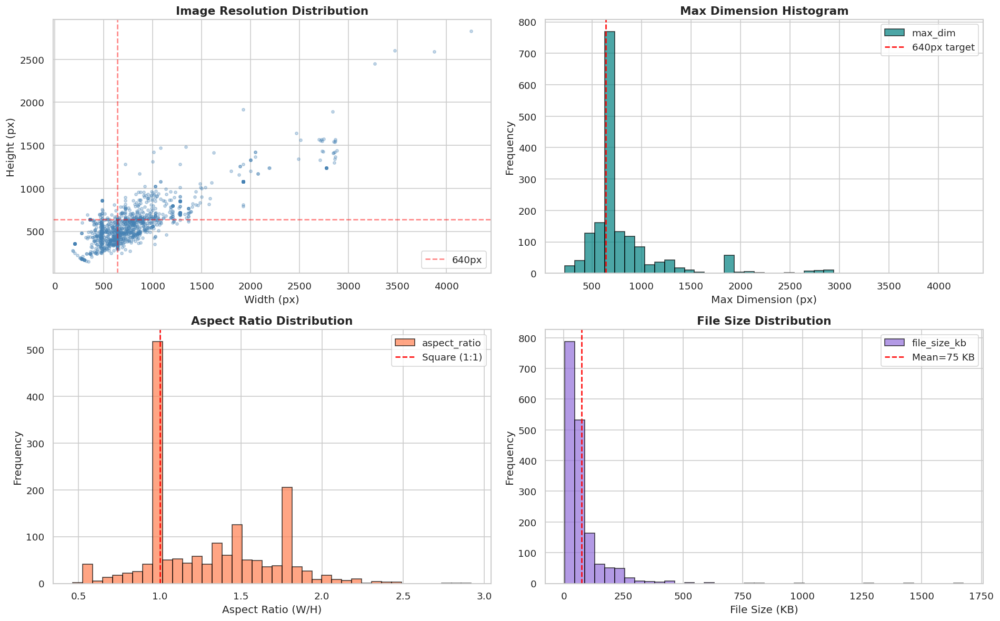


=== Image Dimension & File Statistics ===
  img_width       | min=183  max=4252  mean=792.3  std=446.5
  img_height      | min=147  max=2828  mean=613.5  std=245.3
  aspect_ratio    | min=0  max=3  mean=1.3  std=0.4
  file_size_kb    | min=5  max=1675  mean=75.4  std=97.5

=== File Format Distribution ===


,count
file_ext,
.jpeg,1700


In [6]:
# IMAGE PROPERTIES
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Resolution scatter (Width vs Height)
axes[0, 0].scatter(df_images['img_width'], df_images['img_height'],
                   alpha=0.3, s=10, c='steelblue')
axes[0, 0].set_xlabel('Width (px)')
axes[0, 0].set_ylabel('Height (px)')
axes[0, 0].set_title('Image Resolution Distribution', fontsize=13, fontweight='bold')
axes[0, 0].axhline(y=IMG_SIZE, color='red', linestyle='--', alpha=0.5, label=f'{IMG_SIZE}px')
axes[0, 0].axvline(x=IMG_SIZE, color='red', linestyle='--', alpha=0.5)
axes[0, 0].legend()

# 2. Max dimension histogram
df_images['max_dim'] = df_images[['img_width', 'img_height']].max(axis=1)
df_images['max_dim'].plot.hist(bins=40, ax=axes[0, 1], color='teal',
                                edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Max Dimension (px)')
axes[0, 1].set_title('Max Dimension Histogram', fontsize=13, fontweight='bold')
axes[0, 1].axvline(x=IMG_SIZE, color='red', linestyle='--', label=f'{IMG_SIZE}px target')
axes[0, 1].legend()

# 3. Aspect ratio distribution
df_images['aspect_ratio'].plot.hist(bins=40, ax=axes[1, 0], color='coral',
                                     edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Aspect Ratio (W/H)')
axes[1, 0].set_title('Aspect Ratio Distribution', fontsize=13, fontweight='bold')
axes[1, 0].axvline(x=1.0, color='red', linestyle='--', label='Square (1:1)')
axes[1, 0].legend()

# 4. File size distribution
df_images['file_size_kb'].plot.hist(bins=40, ax=axes[1, 1], color='mediumpurple',
                                     edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('File Size (KB)')
axes[1, 1].set_title('File Size Distribution', fontsize=13, fontweight='bold')
axes[1, 1].axvline(x=df_images['file_size_kb'].mean(), color='red', linestyle='--',
                    label=f"Mean={df_images['file_size_kb'].mean():.0f} KB")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Image Dimension & File Statistics ===")
for col in ['img_width', 'img_height', 'aspect_ratio', 'file_size_kb']:
    s = df_images[col]
    print(f"  {col:15s} | min={s.min():.0f}  max={s.max():.0f}  "
          f"mean={s.mean():.1f}  std={s.std():.1f}")

print(f"\n=== File Format Distribution ===")
display(df_images['file_ext'].value_counts().to_frame('count'))

### 2.4 Bounding-Box Statistics
Count per image, width/height/area distributions, small vs. large object proportion (COCO-style: `<32²`, `32²–96²`, `>96²` pixels).

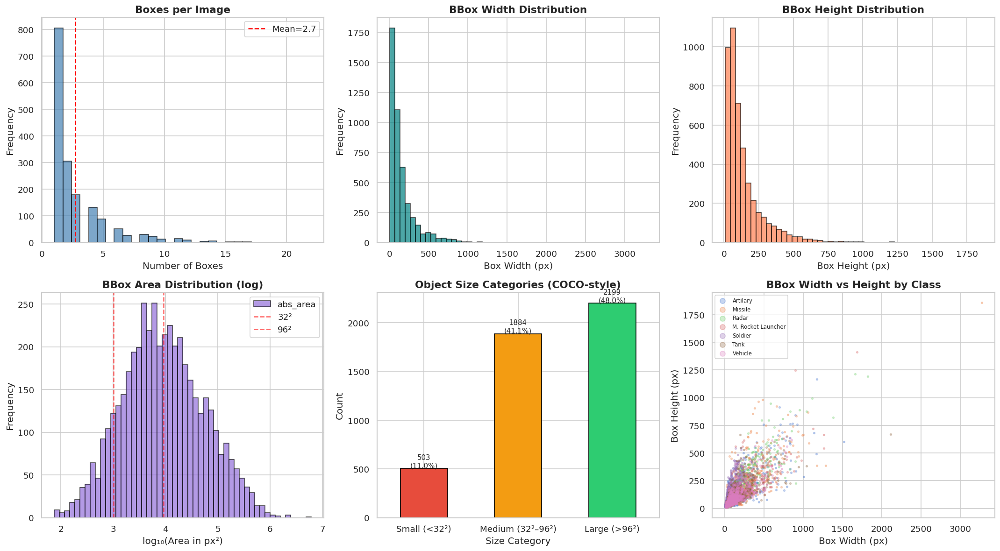


=== BBox Statistics ===
  abs_w      | min=4.7  max=3278.1  mean=156.5  median=94.2
  abs_h      | min=8.2  max=1857.8  mean=139.7  median=90.8
  abs_area   | min=74.6  max=6090058.3  mean=42321.1  median=8399.2

Boxes per image | min=1  max=22  mean=2.7  median=2

=== Object Size Breakdown ===
  Small (<32²)              :   503  (11.0%)
  Medium (32²–96²)          :  1884  (41.1%)
  Large (>96²)              :  2199  (48.0%)


In [7]:
# BOUNDING-BOX STATISTICS
boxes_per_image = df_boxes.groupby('image_stem').size()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Boxes per image histogram
boxes_per_image.plot.hist(bins=30, ax=axes[0, 0], color='steelblue',
                          edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Number of Boxes')
axes[0, 0].set_title('Boxes per Image', fontsize=13, fontweight='bold')
axes[0, 0].axvline(boxes_per_image.mean(), color='red', linestyle='--',
                    label=f'Mean={boxes_per_image.mean():.1f}')
axes[0, 0].legend()

# 2. BBox width distribution (absolute pixels)
df_boxes['abs_w'].plot.hist(bins=50, ax=axes[0, 1], color='teal',
                            edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Box Width (px)')
axes[0, 1].set_title('BBox Width Distribution', fontsize=13, fontweight='bold')

# 3. BBox height distribution
df_boxes['abs_h'].plot.hist(bins=50, ax=axes[0, 2], color='coral',
                            edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Box Height (px)')
axes[0, 2].set_title('BBox Height Distribution', fontsize=13, fontweight='bold')

# 4. BBox area distribution (log scale)
df_boxes['abs_area'].apply(np.log10).plot.hist(bins=50, ax=axes[1, 0],
                                                color='mediumpurple',
                                                edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('log₁₀(Area in px²)')
axes[1, 0].set_title('BBox Area Distribution (log)', fontsize=13, fontweight='bold')
for thresh, label in [(32**2, '32²'), (96**2, '96²')]:
    axes[1, 0].axvline(np.log10(thresh), color='red', linestyle='--', alpha=0.6, label=label)
axes[1, 0].legend()

# 5. Object size categories (COCO-style)
df_boxes['size_cat'] = pd.cut(
    df_boxes['abs_area'],
    bins=[0, 32**2, 96**2, float('inf')],
    labels=['Small (<32²)', 'Medium (32²–96²)', 'Large (>96²)']
)
size_counts = df_boxes['size_cat'].value_counts().sort_index()
size_counts.plot.bar(ax=axes[1, 1], color=['#e74c3c', '#f39c12', '#2ecc71'],
                     edgecolor='black')
axes[1, 1].set_title('Object Size Categories (COCO-style)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Size Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=0)
for i, (cat, cnt) in enumerate(size_counts.items()):
    pct = cnt / len(df_boxes) * 100
    axes[1, 1].text(i, cnt + 10, f'{cnt}\n({pct:.1f}%)', ha='center', fontsize=9)

# 6. BBox width vs height scatter by class
for cid, grp in df_boxes.groupby('class_id'):
    axes[1, 2].scatter(grp['abs_w'], grp['abs_h'], s=5, alpha=0.3,
                        label=CLASS_NAMES[cid])
axes[1, 2].set_xlabel('Box Width (px)')
axes[1, 2].set_ylabel('Box Height (px)')
axes[1, 2].set_title('BBox Width vs Height by Class', fontsize=13, fontweight='bold')
axes[1, 2].legend(fontsize=7, markerscale=3)

plt.tight_layout()
plt.show()

# Numerical summary
print("\n=== BBox Statistics ===")
for col in ['abs_w', 'abs_h', 'abs_area']:
    s = df_boxes[col]
    print(f"  {col:10s} | min={s.min():.1f}  max={s.max():.1f}  "
          f"mean={s.mean():.1f}  median={s.median():.1f}")
print(f"\nBoxes per image | min={boxes_per_image.min()}  max={boxes_per_image.max()}  "
      f"mean={boxes_per_image.mean():.1f}  median={boxes_per_image.median():.0f}")
print(f"\n=== Object Size Breakdown ===")
for cat, cnt in size_counts.items():
    print(f"  {str(cat):25s} : {cnt:5d}  ({cnt/len(df_boxes)*100:.1f}%)")

### 2.5 Bounding-Box Center Heatmap
Visualize spatial distribution of object centers to identify positional biases (e.g., objects concentrated in frame center vs. edges).

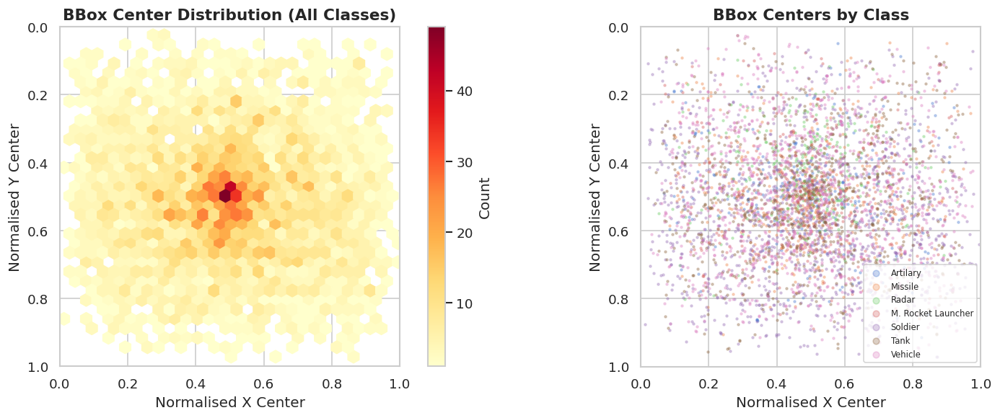

 Heatmap reveals spatial distribution of objects in the frame.
   This helps determine if position-aware augmentations (shift) are needed.


In [8]:
# BBOX CENTER HEATMAP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall heatmap
axes[0].hexbin(df_boxes['cx'], df_boxes['cy'], gridsize=30, cmap='YlOrRd', mincnt=1)
axes[0].set_xlabel('Normalised X Center')
axes[0].set_ylabel('Normalised Y Center')
axes[0].set_title('BBox Center Distribution (All Classes)', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(1, 0)  # Invert Y to match image coordinates
axes[0].set_aspect('equal')
plt.colorbar(axes[0].collections[0], ax=axes[0], label='Count')

# Per-class center scatter
for cid, grp in df_boxes.groupby('class_id'):
    axes[1].scatter(grp['cx'], grp['cy'], s=3, alpha=0.3, label=CLASS_NAMES[cid])
axes[1].set_xlabel('Normalised X Center')
axes[1].set_ylabel('Normalised Y Center')
axes[1].set_title('BBox Centers by Class', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(1, 0)
axes[1].set_aspect('equal')
axes[1].legend(fontsize=7, markerscale=3, loc='lower right')

plt.tight_layout()
plt.show()

print(" Heatmap reveals spatial distribution of objects in the frame.")
print("   This helps determine if position-aware augmentations (shift) are needed.")

### 2.6 Sample Annotated Images
Visualize images with bounding boxes overlaid, covering varying class densities (low, medium, high box counts) to give a qualitative sense of the data.

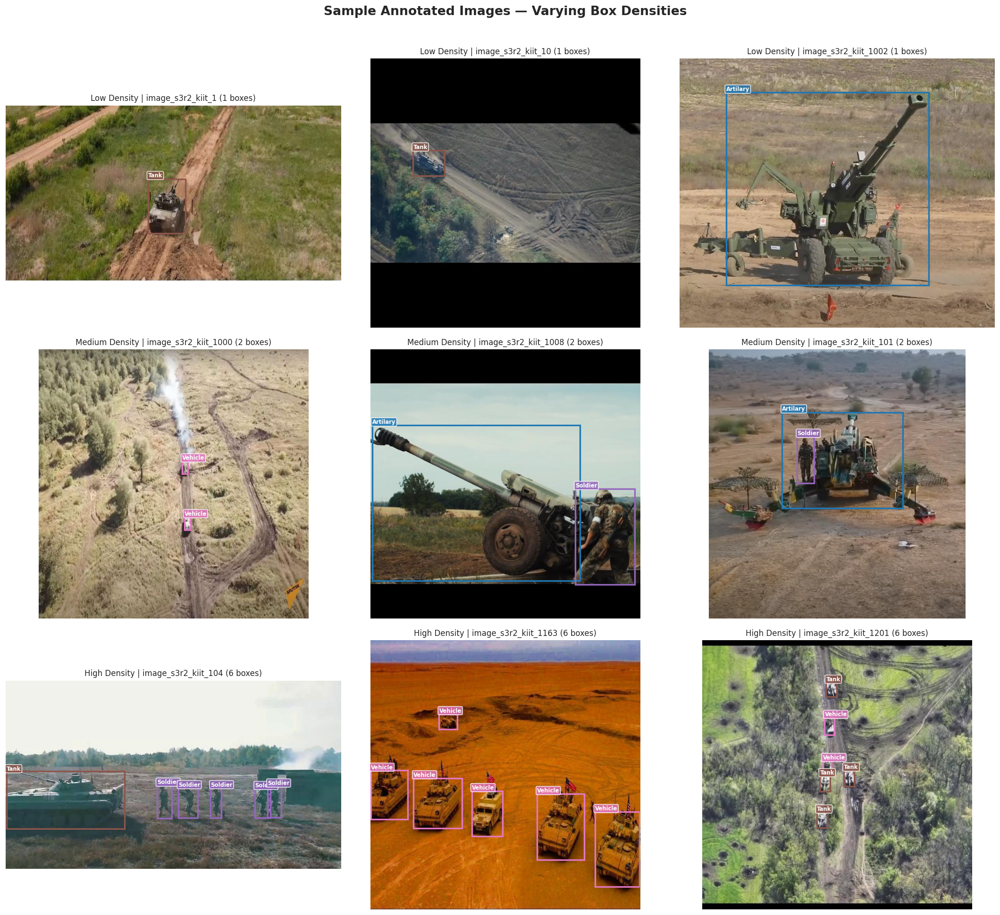

In [9]:
# UNIFIED BOUNDING-BOX DRAWING FUNCTION
def draw_boxes(img, bboxes, class_labels, class_names, ax, title="",
               fmt="yolo_norm", img_hw=None):
    """
    Draw bounding boxes on an image.

    Parameters
    ----------
    img : np.ndarray or path-like
        Image array (H, W, 3) or path to image file.
    bboxes : list of tuples
        Bounding boxes. Format depends on `fmt`.
    class_labels : list of int
        Class IDs corresponding to each bbox.
    class_names : list of str
        Mapping from class ID to name.
    ax : matplotlib Axes
        Axes to draw on.
    title : str
        Title for the subplot.
    fmt : str
        "yolo_norm" → (cx, cy, w, h) normalised [0,1]
        "yolo_file" → read boxes from label file path (bboxes=label_path)
    """
    if isinstance(img, (str, Path)):
        img = np.array(Image.open(img).convert('RGB'))

    h, w = img.shape[:2]
    ax.imshow(img)

    cmap = plt.colormaps['tab10']
    boxes_to_draw = []

    if fmt == "yolo_file" and isinstance(bboxes, (str, Path)):
        lbl_path = Path(bboxes)
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cid = int(parts[0])
                        cx, cy, bw, bh = map(float, parts[1:5])
                        boxes_to_draw.append((cid, cx, cy, bw, bh))
    else:
        for (cx, cy, bw, bh), cid in zip(bboxes, class_labels):
            boxes_to_draw.append((int(cid), cx, cy, bw, bh))

    for cid, cx, cy, bw, bh in boxes_to_draw:
        x1 = (cx - bw / 2) * w
        y1 = (cy - bh / 2) * h
        box_w = bw * w
        box_h = bh * h

        color = cmap(cid % 10)
        rect = patches.Rectangle((x1, y1), box_w, box_h,
                                 linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        name = class_names[cid] if cid < len(class_names) else f"UNK_{cid}"
        ax.text(x1, max(y1 - 4, 10), name, fontsize=7, fontweight='bold',
                color='white', bbox=dict(boxstyle='round,pad=0.2',
                                          facecolor=color, alpha=0.8))
    ax.set_title(title, fontsize=10)
    ax.axis('off')


# SAMPLE ANNOTATED IMAGES
# Select samples from the first available split with varying box counts
first_split = list(ORIG_SPLITS.keys())[0]
boxes_per_img = df_boxes[df_boxes['split'] == first_split].groupby('image_stem').size()
quantiles = boxes_per_img.quantile([0.1, 0.5, 0.9]).values

sample_stems = []
density_labels = ['Low Density', 'Medium Density', 'High Density']
for q in quantiles:
    closest = (boxes_per_img - q).abs().nsmallest(3).index.tolist()
    sample_stems.append(closest)

fig, axes = plt.subplots(3, 3, figsize=(18, 16))

for row, (stems, density) in enumerate(zip(sample_stems, density_labels)):
    for col, stem in enumerate(stems):
        # Find image file dynamically (don't hardcode extension)
        img_dir = ORIG_SPLITS[first_split] / 'images'
        img_path = next(img_dir.glob(f"{stem}.*"), None)
        lbl_path = ORIG_SPLITS[first_split] / 'labels' / f"{stem}.txt"
        n_boxes = boxes_per_img.get(stem, 0)

        if img_path is not None:
            draw_boxes(img_path, lbl_path, [], CLASS_NAMES, axes[row, col],
                       title=f"{density} | {stem} ({n_boxes} boxes)", fmt="yolo_file")
        else:
            axes[row, col].text(0.5, 0.5, f"Image not found: {stem}",
                                ha='center', transform=axes[row, col].transAxes)

plt.suptitle('Sample Annotated Images — Varying Box Densities',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Train / Validation / Test Splitting — Data Leakage Prevention

> ** Data leakage is a specific grading focus this term.**

Our leakage prevention strategy has **three layers**:

1. **Exact duplicate detection** — MD5 hash of every image to catch byte-identical copies across splits.
2. **Near-duplicate detection** — Perceptual hashing (pHash) to catch visually similar images (e.g., consecutive drone frames from the same flyover).
3. **Filename/sequence analysis** — Analyse naming patterns to detect burst-captured or video-extracted frame groups.

After leakage checks, we perform a **stratified split** using the dominant class per image as the stratification key.

In [10]:
# LAYER 1: MD5 HASH — EXACT DUPLICATE DETECTION
def compute_md5(filepath):
    """Compute MD5 hash of a file for exact duplicate detection."""
    h = hashlib.md5()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()

# Pool ALL images from ALL original splits into a single set
all_images = []
for split_name, split_path in ORIG_SPLITS.items():
    img_dir = split_path / 'images'
    if not img_dir.exists():
        continue
    for img_path in sorted(img_dir.glob('*')):
        all_images.append({
            'orig_split': split_name,
            'stem': img_path.stem,
            'img_path': img_path,
            'lbl_path': split_path / 'labels' / f"{img_path.stem}.txt",
            'ext': img_path.suffix,
        })

print(f"Total images pooled from all splits: {len(all_images)}")

# Compute MD5 hashes
print("Computing MD5 hashes for exact duplicate detection...")
for rec in tqdm(all_images, desc='MD5 Hashing'):
    rec['md5'] = compute_md5(rec['img_path'])

df_pool = pd.DataFrame(all_images)

# Detect exact duplicates
hash_counts = df_pool.groupby('md5').agg(
    count=('stem', 'size'),
    splits=('orig_split', lambda x: set(x)),
    stems=('stem', list)
).reset_index()

duplicates = hash_counts[hash_counts['count'] > 1]
cross_split_dupes = duplicates[duplicates['splits'].apply(len) > 1]

print(f"\n=== MD5 Exact Duplicate Detection ===")
print(f"Unique hashes         : {len(hash_counts)}")
print(f"Duplicate groups      : {len(duplicates)}")
print(f"Cross-split leaks     : {len(cross_split_dupes)}")

if len(cross_split_dupes) > 0:
    print("\n  CROSS-SPLIT DATA LEAKAGE DETECTED:")
    for _, row in cross_split_dupes.iterrows():
        print(f"  Hash {row['md5'][:12]}... appears in splits {row['splits']}")
        print(f"    Stems: {row['stems'][:5]}")
else:
    print(" No exact cross-split duplicates found.")

if len(duplicates) > 0:
    print(f"\n  {len(duplicates)} duplicate groups found within splits. Keeping first occurrence only.")
    df_pool = df_pool.drop_duplicates(subset='md5', keep='first').reset_index(drop=True)
    print(f"   After deduplication: {len(df_pool)} unique images.")
else:
    print(" No exact duplicate images found anywhere in the dataset.")

Total images pooled from all splits: 1700
Computing MD5 hashes for exact duplicate detection...


MD5 Hashing:   0%|          | 0/1700 [00:00<?, ?it/s]


=== MD5 Exact Duplicate Detection ===
Unique hashes         : 1681
Duplicate groups      : 19
Cross-split leaks     : 8

  CROSS-SPLIT DATA LEAKAGE DETECTED:
  Hash 03a82276bc1f... appears in splits {'valid', 'train'}
    Stems: ['image_s3r2_kiit_428', 'image_s3r2_kiit_1079']
  Hash 16a24bd0d4be... appears in splits {'test', 'train'}
    Stems: ['image_s3r2_kiit_1239', 'image_s3r2_kiit_464']
  Hash 4094977534da... appears in splits {'test', 'train'}
    Stems: ['image_s3r2_kiit_566', 'image_s3r2_kiit_281']
  Hash 4da5bb5ea064... appears in splits {'test', 'train'}
    Stems: ['image_s3r2_kiit_972', 'image_s3r2_kiit_813']
  Hash 54243b9d9d6d... appears in splits {'valid', 'train'}
    Stems: ['image_s3r2_kiit_1484', 'image_s3r2_kiit_1038']
  Hash 650e0414b470... appears in splits {'test', 'train'}
    Stems: ['image_s3r2_kiit_1151', 'image_s3r2_kiit_60']
  Hash 6f8edbaa9732... appears in splits {'valid', 'train'}
    Stems: ['image_s3r2_kiit_1164', 'image_s3r2_kiit_914']
  Hash 81f8f53

In [11]:
# LAYER 2: PERCEPTUAL HASH — NEAR-DUPLICATE DETECTION
def compute_dhash(img_path, hash_size=8):
    """
    Compute difference hash (dHash) of an image.
    Returns a binary string of length hash_size² bits.
    dHash is robust to minor scaling and compression differences.
    """
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    resized = cv2.resize(img, (hash_size + 1, hash_size))
    diff = resized[:, 1:] > resized[:, :-1]
    return diff.flatten()

def hamming_distance(hash1, hash2):
    """Compute Hamming distance between two binary hash arrays."""
    return np.sum(hash1 != hash2)

# Compute perceptual hashes for all pooled images
print("Computing perceptual hashes (dHash) for near-duplicate detection...")
phashes = []
for _, row in tqdm(df_pool.iterrows(), total=len(df_pool), desc='dHash'):
    h = compute_dhash(row['img_path'])
    phashes.append(h)
df_pool['phash'] = phashes

# Find near-duplicate pairs (Hamming distance ≤ threshold)
valid_hashes = df_pool.dropna(subset=['phash'])
print(f"\nComparing {len(valid_hashes)} images for near-duplicates (threshold={PHASH_THRESHOLD})...")

hash_arrays = np.array(valid_hashes['phash'].tolist())
stems_arr = valid_hashes['stem'].values
splits_arr = valid_hashes['orig_split'].values

diff = hash_arrays[:, None, :] != hash_arrays[None, :, :]
dists = np.sum(diff, axis=-1)

iu, ju = np.triu_indices(len(hash_arrays), k=1)
pair_dists = dists[iu, ju]
matches = pair_dists <= PHASH_THRESHOLD

near_dup_pairs = [
    {
        'stem_a': stems_arr[i],
        'stem_b': stems_arr[j],
        'split_a': splits_arr[i],
        'split_b': splits_arr[j],
        'hamming_dist': int(dists[i, j]),
        'cross_split': splits_arr[i] != splits_arr[j],
    }
    for i, j in zip(iu[matches], ju[matches])
]

df_near_dups = pd.DataFrame(near_dup_pairs)

print(f"\n=== Near-Duplicate Detection Results ===")
print(f"Near-duplicate pairs found : {len(df_near_dups)}")

if len(df_near_dups) > 0:
    cross_split_near = df_near_dups[df_near_dups['cross_split']]
    print(f"Cross-split near-dupes     : {len(cross_split_near)}")

    if len(cross_split_near) > 0:
        print("\n  CROSS-SPLIT NEAR-DUPLICATE LEAKAGE:")
        display(cross_split_near.head(10))
    else:
        print(" All near-duplicates are within the same split (no cross-split leakage).")

    # Build groups of near-duplicates for group-aware splitting
    from collections import defaultdict

    dup_groups = defaultdict(set)
    for _, row in df_near_dups.iterrows():
        dup_groups[row['stem_a']].add(row['stem_b'])
        dup_groups[row['stem_b']].add(row['stem_a'])

    # Merge connected components
    visited = set()
    groups = []
    for stem in dup_groups:
        if stem in visited:
            continue
        group = set()
        stack = [stem]
        while stack:
            s = stack.pop()
            if s in visited:
                continue
            visited.add(s)
            group.add(s)
            stack.extend(dup_groups.get(s, set()))
        groups.append(group)

    print(f"\nNear-duplicate groups : {len(groups)}")
    print(f"Max group size       : {max(len(g) for g in groups)}")
    print("These groups will be kept together during splitting.")
else:
    groups = []
    print(" No near-duplicate images detected.")
    print("   This suggests the dataset images are sufficiently distinct.")

Computing perceptual hashes (dHash) for near-duplicate detection...


dHash:   0%|          | 0/1681 [00:00<?, ?it/s]


Comparing 1681 images for near-duplicates (threshold=10)...

=== Near-Duplicate Detection Results ===
Near-duplicate pairs found : 125
Cross-split near-dupes     : 35

  CROSS-SPLIT NEAR-DUPLICATE LEAKAGE:


,stem_a,stem_b,split_a,split_b,hamming_dist,cross_split
1,image_s3r2_kiit_10,image_s3r2_kiit_1385,train,test,9,True
2,image_s3r2_kiit_1011,image_s3r2_kiit_1313,train,test,9,True
20,image_s3r2_kiit_1104,image_s3r2_kiit_1251,train,test,1,True
32,image_s3r2_kiit_1163,image_s3r2_kiit_1020,train,test,5,True
34,image_s3r2_kiit_118,image_s3r2_kiit_1456,train,valid,4,True
46,image_s3r2_kiit_1280,image_s3r2_kiit_1385,train,test,2,True
49,image_s3r2_kiit_1315,image_s3r2_kiit_195,train,valid,10,True
52,image_s3r2_kiit_138,image_s3r2_kiit_759,train,test,7,True
53,image_s3r2_kiit_1388,image_s3r2_kiit_968,train,valid,3,True
57,image_s3r2_kiit_1415,image_s3r2_kiit_1251,train,test,3,True



Near-duplicate groups : 89
Max group size       : 5
These groups will be kept together during splitting.


=== Filename Pattern Analysis ===
Unique prefixes: 1


,count
prefix,
image_s3r2_kiit_,1681



File number range    : 1 – 1700
Consecutive pairs    : 1661 / 1680
Sequential density   : 98.9%

  HIGH SEQUENTIAL DENSITY — images may be video frames.
   Group-aware splitting is STRONGLY recommended.


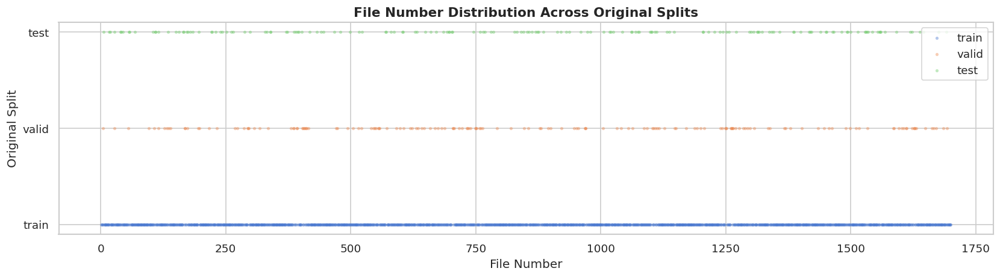


 If numbers are evenly spread across splits, the original split is likely random (good).
   If clusters exist within splits, the split may be sequential/temporal (potential leakage).


In [12]:
# LAYER 3: FILENAME / SEQUENCE ANALYSIS

# Extract numeric suffix from filenames
df_pool['file_number'] = df_pool['stem'].str.extract(r'(\d+)$').astype(float)

# Analyse filename prefix patterns
df_pool['prefix'] = df_pool['stem'].str.replace(r'\d+$', '', regex=True)
prefix_counts = df_pool['prefix'].value_counts()

print("=== Filename Pattern Analysis ===")
print(f"Unique prefixes: {len(prefix_counts)}")
display(prefix_counts.to_frame('count'))

# Check if sequential numbers might indicate temporal proximity
if df_pool['file_number'].notna().all():
    sorted_nums = df_pool.sort_values('file_number')['file_number'].values
    diffs = np.diff(sorted_nums)
    consecutive = np.sum(diffs == 1)
    print(f"\nFile number range    : {int(sorted_nums.min())} – {int(sorted_nums.max())}")
    print(f"Consecutive pairs    : {consecutive} / {len(diffs)}")
    print(f"Sequential density   : {consecutive / len(diffs) * 100:.1f}%")

    if consecutive / len(diffs) > 0.5:
        print("\n  HIGH SEQUENTIAL DENSITY — images may be video frames.")
        print("   Group-aware splitting is STRONGLY recommended.")
    else:
        print("\n Low sequential density — images appear independently captured.")

# Visual: Distribution of file numbers per original split
fig, ax = plt.subplots(figsize=(14, 4))
for split_name in ORIG_SPLITS:
    subset = df_pool[df_pool['orig_split'] == split_name]
    if 'file_number' in subset.columns and subset['file_number'].notna().any():
        ax.scatter(subset['file_number'], [split_name] * len(subset),
                   alpha=0.3, s=5, label=split_name)
ax.set_xlabel('File Number')
ax.set_ylabel('Original Split')
ax.set_title('File Number Distribution Across Original Splits', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\n If numbers are evenly spread across splits, the original split is likely random (good).")
print("   If clusters exist within splits, the split may be sequential/temporal (potential leakage).")

In [13]:
# STRATIFIED SPLITTING
from sklearn.model_selection import train_test_split

# Determine dominant class per image for stratification
def get_dominant_class(stem, df_boxes_full):
    """Return the most frequent class_id in the label file for an image."""
    img_boxes = df_boxes_full[df_boxes_full['image_stem'] == stem]
    if len(img_boxes) == 0:
        return -1  # no labels
    return img_boxes['class_id'].mode().iloc[0]

df_pool['dominant_class'] = df_pool['stem'].apply(
    lambda s: get_dominant_class(s, df_boxes)
)

print("Dominant class distribution for stratification:")
dom_dist = df_pool['dominant_class'].value_counts().sort_index()
for cid, cnt in dom_dist.items():
    name = CLASS_NAMES[cid] if 0 <= cid < NUM_CLASSES else "No Label"
    print(f"  {cid}: {name} → {cnt} images")

# Group-aware splitting
if len(groups) > 0:
    stem_to_group = {}
    for gid, grp in enumerate(groups):
        for s in grp:
            stem_to_group[s] = gid
    # Ungrouped images get unique group IDs
    next_gid = len(groups)
    for stem in df_pool['stem']:
        if stem not in stem_to_group:
            stem_to_group[stem] = next_gid
            next_gid += 1
    df_pool['group_id'] = df_pool['stem'].map(stem_to_group)

    # Split by group (each group goes entirely to one split)
    group_info = df_pool.groupby('group_id').agg(
        dominant_class=('dominant_class', lambda x: x.mode().iloc[0]),
        size=('stem', 'size')
    ).reset_index()

    g_train, g_valtest = train_test_split(
        group_info['group_id'].values,
        test_size=(VAL_RATIO + TEST_RATIO),
        random_state=SEED,
        stratify=group_info['dominant_class'].values
    )
    g_valtest_info = group_info[group_info['group_id'].isin(g_valtest)]
    relative_test = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
    g_val, g_test = train_test_split(
        g_valtest_info['group_id'].values,
        test_size=relative_test,
        random_state=SEED,
        stratify=g_valtest_info['dominant_class'].values
    )

    stems_train = df_pool[df_pool['group_id'].isin(g_train)]['stem'].values
    stems_val = df_pool[df_pool['group_id'].isin(g_val)]['stem'].values
    stems_test = df_pool[df_pool['group_id'].isin(g_test)]['stem'].values
    print(f"\n Group-aware splitting applied ({len(groups)} near-duplicate groups kept together).")
else:
    # Standard stratified split (no groups needed)
    stems_train, stems_valtest, _, y_valtest = train_test_split(
        df_pool['stem'].values,
        df_pool['dominant_class'].values,
        test_size=(VAL_RATIO + TEST_RATIO),
        random_state=SEED,
        stratify=df_pool['dominant_class'].values
    )
    relative_test = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
    stems_val, stems_test, _, _ = train_test_split(
        stems_valtest,
        y_valtest,
        test_size=relative_test,
        random_state=SEED,
        stratify=y_valtest
    )
    print("\n Standard stratified split applied (no near-duplicate groups detected).")

print(f"\n=== New Split Sizes ===")
print(f"  Train : {len(stems_train):5d}  ({len(stems_train)/len(df_pool)*100:.1f}%)")
print(f"  Val   : {len(stems_val):5d}  ({len(stems_val)/len(df_pool)*100:.1f}%)")
print(f"  Test  : {len(stems_test):5d}  ({len(stems_test)/len(df_pool)*100:.1f}%)")
print(f"  Total : {len(stems_train)+len(stems_val)+len(stems_test)}")

# Final leakage verification — no overlap between any splits
assert len(set(stems_train) & set(stems_val)) == 0, "Train/Val overlap!"
assert len(set(stems_train) & set(stems_test)) == 0, "Train/Test overlap!"
assert len(set(stems_val) & set(stems_test)) == 0, "Val/Test overlap!"
print("\n No overlap between any splits — leakage-free split confirmed.")

Dominant class distribution for stratification:
  0: Artilary → 138 images
  1: Missile → 268 images
  2: Radar → 228 images
  3: M. Rocket Launcher → 219 images
  4: Soldier → 229 images
  5: Tank → 300 images
  6: Vehicle → 299 images

 Group-aware splitting applied (89 near-duplicate groups kept together).

=== New Split Sizes ===
  Train :  1339  (79.7%)
  Val   :   164  (9.8%)
  Test  :   178  (10.6%)
  Total : 1681

 No overlap between any splits — leakage-free split confirmed.


=== Stratification Report: Per-Split Class Counts ===


,Train,Val,Test,Total,Train %,Val %,Test %
class_name,,,,,,,
Artilary,240,29,28,297,80.8,9.8,9.4
Missile,362,40,45,447,81.0,8.9,10.1
Radar,225,33,29,287,78.4,11.5,10.1
M. Rocket Launcher,311,33,36,380,81.8,8.7,9.5
Soldier,907,113,92,1112,81.6,10.2,8.3
Tank,643,81,94,818,78.6,9.9,11.5
Vehicle,881,93,159,1133,77.8,8.2,14.0


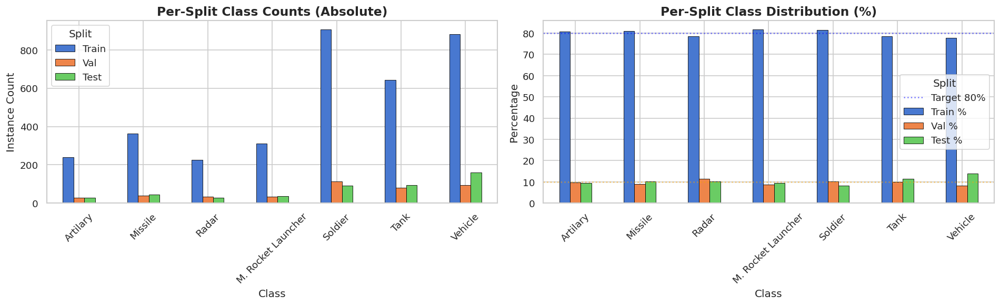


 Class proportions are preserved across all splits (stratified).
   Each class maintains approximately 80/10/10 distribution.


In [14]:
# STRATIFICATION VERIFICATION
def count_classes_in_split(stems, df_boxes_full, class_names):
    """Count instances of each class for a set of image stems."""
    subset = df_boxes_full[df_boxes_full['image_stem'].isin(stems)]
    counts = subset['class_name'].value_counts()
    return counts.reindex(class_names, fill_value=0)

split_map = {'Train': stems_train, 'Val': stems_val, 'Test': stems_test}
strat_report = pd.DataFrame({
    name: count_classes_in_split(stems, df_boxes, CLASS_NAMES)
    for name, stems in split_map.items()
})
strat_report['Total'] = strat_report.sum(axis=1)

# Add percentage columns
for col in ['Train', 'Val', 'Test']:
    strat_report[f'{col} %'] = (strat_report[col] / strat_report['Total'] * 100).round(1)

print("=== Stratification Report: Per-Split Class Counts ===")
display(strat_report)

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

strat_report[['Train', 'Val', 'Test']].plot.bar(ax=axes[0], edgecolor='black', linewidth=0.5)
axes[0].set_title('Per-Split Class Counts (Absolute)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Instance Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Split')

# Percentage comparison (should be ~80/10/10 for all classes)
strat_report[['Train %', 'Val %', 'Test %']].plot.bar(ax=axes[1], edgecolor='black', linewidth=0.5)
axes[1].set_title('Per-Split Class Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=TRAIN_RATIO*100, color='blue', linestyle=':', alpha=0.5, label=f'Target {TRAIN_RATIO*100:.0f}%')
axes[1].axhline(y=VAL_RATIO*100, color='orange', linestyle=':', alpha=0.5)
axes[1].legend(title='Split')

plt.tight_layout()
plt.show()

print("\n Class proportions are preserved across all splits (stratified).")
print("   Each class maintains approximately 80/10/10 distribution.")

In [15]:
# COPY FILES TO RE-SPLIT DIRECTORY
def copy_split_files(stems, df_pool, resplit_root, split_name):
    """Copy image and label files for the given stems into the re-split directory."""
    img_dir = resplit_root / split_name / 'images'
    lbl_dir = resplit_root / split_name / 'labels'
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    stem_set = set(stems)
    copied = 0
    for _, row in df_pool.iterrows():
        if row['stem'] in stem_set:
            # Copy image
            src_img = row['img_path']
            dst_img = img_dir / f"{row['stem']}{row['ext']}"
            shutil.copy2(str(src_img), str(dst_img))

            # Copy label
            src_lbl = row['lbl_path']
            if Path(src_lbl).exists():
                dst_lbl = lbl_dir / f"{row['stem']}.txt"
                shutil.copy2(str(src_lbl), str(dst_lbl))
            copied += 1
    return copied

# Create re-split dataset
print("Copying files to re-split directory...")
for split_name, stems in [('train', stems_train), ('val', stems_val), ('test', stems_test)]:
    n = copy_split_files(stems, df_pool, RESPLIT_ROOT, split_name)
    print(f"  {split_name}: {n} images copied")

# Verify counts
print("\n=== Re-Split Directory Verification ===")
for split_name in ['train', 'val', 'test']:
    n_img = len(list((RESPLIT_ROOT / split_name / 'images').glob('*')))
    n_lbl = len(list((RESPLIT_ROOT / split_name / 'labels').glob('*')))
    print(f"  {split_name}: {n_img} images, {n_lbl} labels")

# Write data.yaml with RELATIVE paths
yaml_lines = ["# Auto-generated by Notebook 1 — Dataset Exploration & Preprocessing"]
yaml_lines.append(f"# Generated for: KIIT-MiTA Military Target Detection Dataset")
yaml_lines.append(f"# Split ratios: {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}")
yaml_lines.append(f"# NOTE: train/val/test below are RELATIVE to this file's own directory.")
yaml_lines.append(f"# Downstream notebooks must resolve them against wherever this file is")
yaml_lines.append(f"# actually found, not against the current working directory.")
yaml_lines.append(f"")
yaml_lines.append(f"train: train/images")
yaml_lines.append(f"val: val/images")
yaml_lines.append(f"test: test/images")
yaml_lines.append(f"")
yaml_lines.append(f"nc: {NUM_CLASSES}")
yaml_lines.append(f"names:")
for name in CLASS_NAMES:
    yaml_lines.append(f"  - {name}")

yaml_content = "\n".join(yaml_lines) + "\n"
yaml_path = RESPLIT_ROOT / 'data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"\n data.yaml written to: {yaml_path}")
print(f"   (paths inside are RELATIVE — resolve them against data.yaml's own folder,")
print(f"    not against the current working directory, in every downstream notebook)")
print(f"\n--- data.yaml contents ---")
print(yaml_content)

Copying files to re-split directory...
  train: 1339 images copied
  val: 164 images copied
  test: 178 images copied

=== Re-Split Directory Verification ===
  train: 1339 images, 1339 labels
  val: 164 images, 164 labels
  test: 178 images, 178 labels

 data.yaml written to: /kaggle/working/dataset-resplit/data.yaml
   (paths inside are RELATIVE — resolve them against data.yaml's own folder,
    not against the current working directory, in every downstream notebook)

--- data.yaml contents ---
# Auto-generated by Notebook 1 — Dataset Exploration & Preprocessing
# Generated for: KIIT-MiTA Military Target Detection Dataset
# Split ratios: 0.8/0.1/0.1
# NOTE: train/val/test below are RELATIVE to this file's own directory.
# Downstream notebooks must resolve them against wherever this file is
# actually found, not against the current working directory.

train: train/images
val: val/images
test: test/images

nc: 7
names:
  - Artilary
  - Missile
  - Radar
  - M. Rocket Launcher
  - Soldi

### Augmentation Justifications

| Transform | Type | p | Justification |
|---|---|---|---|
| **HorizontalFlip** | Geometric | 0.5 | Military targets appear from any horizontal direction in aerial view. |
| **ShiftScaleRotate** (rotate disabled) | Geometric | 0.6 | Scale/shift covers object-size and position variation. `rotate_limit=0` — rotation was tested during YOLO training (Notebook 2) and caused a measurable mAP regression across all three models, since these are canonical top-down frames of rigid hardware where silhouette orientation is itself a signal the model relies on, not noise to be augmented away. Excluded on that empirical basis, not just guessed. |
| **RandomBrightnessContrast / HueSaturationValue / CLAHE** (one of, capped) | Photometric | 0.5 | Covers lighting and environment variation (day/dusk, desert/forest/urban) without stacking every photometric transform on the same image. |

**Excluded:** `RandomRotate90` and vertical flip (`VerticalFlip`/`flipud`) — both were tried and rejected for the same canonical-orientation reason above; a rotated or vertically-mirrored target does not resemble a real top-down capture of that object.


In [16]:
_alb_version = tuple(int(x) for x in A.__version__.split('.')[:2])

_train_transforms = [
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=0,
                        border_mode=cv2.BORDER_CONSTANT, value=0, p=0.6),
    A.SomeOf([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=1.0),
        A.CLAHE(clip_limit=2.0, p=1.0),
    ], n=1, p=0.5),
]

train_transform = A.Compose(
    _train_transforms,
    bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_area=16, min_visibility=0.2)
)

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

print(f"Albumentations version: {A.__version__}")
print(f"train_transform: {len(train_transform.transforms)} top-level steps (rotation disabled, see justification above)")
print(f"val_transform: {len(val_transform.transforms)} top-level steps (documentation only, val/test files on disk stay untouched)")


Albumentations version: 2.0.8
train_transform: 4 top-level steps (rotation disabled, see justification above)
val_transform: 1 top-level steps (documentation only, val/test files on disk stay untouched)


### 4.1 Minority-Class Balancing — Copy-Paste Augmentation (Train Split Only)

Whole-image oversampling was tried first but has a structural problem: duplicating an image to boost one class also duplicates every other class present in that frame, inflating already-adequate classes as a side effect.

Copy-paste avoids this by extracting only the target class's bounding-box crop and pasting it onto a different receiver image, rather than duplicating a whole scene. Receivers are chosen to minimize existing content (fewest current instances), and placements that would heavily overlap an existing box are rejected and retried. Train split only, applied after the leakage-safe split, so no leakage risk.

In [17]:
def load_image_and_labels(img_path, lbl_path):
    img = np.array(Image.open(img_path).convert('RGB'))
    bboxes, class_labels = [], []
    if Path(lbl_path).exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cid = int(float(parts[0]))
                    cx, cy, w, h = map(float, parts[1:5])
                    bboxes.append([cx, cy, w, h])
                    class_labels.append(cid)
    return img, bboxes, class_labels

def clip_bbox(bboxes, eps=1e-6):
    clipped = []
    for cx, cy, w, h in bboxes:
        x_min = max(0.0, cx - w / 2)
        y_min = max(0.0, cy - h / 2)
        x_max = min(1.0, cx + w / 2)
        y_max = min(1.0, cy + h / 2)
        new_w = max(x_max - x_min, eps)
        new_h = max(y_max - y_min, eps)
        new_cx = x_min + new_w / 2
        new_cy = y_min + new_h / 2
        clipped.append([min(max(new_cx, 0.0), 1.0), min(max(new_cy, 0.0), 1.0),
                         min(new_w, 1.0), min(new_h, 1.0)])
    return clipped

def iou_yolo(box_a, box_b):
    ax1, ay1 = box_a[0] - box_a[2] / 2, box_a[1] - box_a[3] / 2
    ax2, ay2 = box_a[0] + box_a[2] / 2, box_a[1] + box_a[3] / 2
    bx1, by1 = box_b[0] - box_b[2] / 2, box_b[1] - box_b[3] / 2
    bx2, by2 = box_b[0] + box_b[2] / 2, box_b[1] + box_b[3] / 2
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    union = box_a[2] * box_a[3] + box_b[2] * box_b[3] - inter
    return inter / union if union > 0 else 0.0

def try_paste(receiver_img, receiver_bboxes, crop_img, max_iou=0.15, max_tries=10):
    h, w = receiver_img.shape[:2]
    ch, cw = crop_img.shape[:2]
    for _ in range(max_tries):
        scale = np.random.uniform(0.85, 1.15)
        new_w = max(4, int(cw * scale))
        new_h = max(4, int(ch * scale))
        if new_w >= w or new_h >= h:
            continue
        x0 = np.random.randint(0, w - new_w)
        y0 = np.random.randint(0, h - new_h)
        new_box = [(x0 + new_w / 2) / w, (y0 + new_h / 2) / h, new_w / w, new_h / h]
        if any(iou_yolo(new_box, b) > max_iou for b in receiver_bboxes):
            continue
        resized_crop = cv2.resize(crop_img, (new_w, new_h))
        out_img = receiver_img.copy()
        out_img[y0:y0 + new_h, x0:x0 + new_w] = resized_crop
        return out_img, new_box
    return None, None

train_img_dir = RESPLIT_ROOT / 'train' / 'images'
train_lbl_dir = RESPLIT_ROOT / 'train' / 'labels'

train_box_df = df_boxes[df_boxes['image_stem'].isin(stems_train)]
train_instance_counts = train_box_df['class_name'].value_counts().reindex(CLASS_NAMES, fill_value=0)
print("Train instance counts (before copy-paste):")
print(train_instance_counts)

TARGET_RATIO = 0.6
target_instances = int(train_instance_counts.max() * TARGET_RATIO)
print(f"\nTarget instance count per class: {target_instances}")

crops_by_class = defaultdict(list)
for stem, grp in train_box_df.groupby('image_stem'):
    img_path = next(train_img_dir.glob(f"{stem}.*"), None)
    if img_path is None:
        continue
    img = np.array(Image.open(img_path).convert('RGB'))
    h, w = img.shape[:2]
    for _, row in grp.iterrows():
        cx, cy, bw, bh = row['cx'], row['cy'], row['w'], row['h']
        x1 = max(0, int((cx - bw / 2) * w))
        y1 = max(0, int((cy - bh / 2) * h))
        x2 = min(w, int((cx + bw / 2) * w))
        y2 = min(h, int((cy + bh / 2) * h))
        if x2 - x1 < 4 or y2 - y1 < 4:
            continue
        crops_by_class[row['class_name']].append(img[y1:y2, x1:x2].copy())

total_instances_per_stem = train_box_df.groupby('image_stem').size()
train_stems_sorted_by_simplicity = sorted(stems_train, key=lambda s: total_instances_per_stem.get(s, 0))

pasted_instances_added = Counter()
pasted_images_written = Counter()
new_stem_counter = 0

for class_name in CLASS_NAMES:
    current = train_instance_counts[class_name]
    deficit = target_instances - current
    if deficit <= 0:
        continue
    crops = crops_by_class.get(class_name, [])
    if not crops:
        print(f"  WARNING: no crops available for {class_name} — cannot copy-paste.")
        continue

    covered = 0
    pbar = tqdm(total=deficit, desc=f'Copy-paste {class_name}')
    receiver_pool_idx = 0
    tries = 0
    max_tries_total = deficit * 20

    while covered < deficit and tries < max_tries_total:
        tries += 1
        receiver_stem = train_stems_sorted_by_simplicity[receiver_pool_idx % len(train_stems_sorted_by_simplicity)]
        receiver_pool_idx += 1

        receiver_img_path = next(train_img_dir.glob(f"{receiver_stem}.*"), None)
        receiver_lbl_path = train_lbl_dir / f"{receiver_stem}.txt"
        if receiver_img_path is None:
            continue
        receiver_img, receiver_bboxes, receiver_labels = load_image_and_labels(receiver_img_path, receiver_lbl_path)
        receiver_bboxes = clip_bbox(receiver_bboxes)

        crop = crops[np.random.randint(len(crops))]
        out_img, new_box = try_paste(receiver_img, receiver_bboxes, crop)
        if out_img is None:
            continue

        new_stem_counter += 1
        new_stem = f"cp_{class_name.replace(' ', '').replace('.', '')}_{new_stem_counter}"
        new_img_path = train_img_dir / f"{new_stem}{receiver_img_path.suffix}"
        new_lbl_path = train_lbl_dir / f"{new_stem}.txt"

        Image.fromarray(out_img).save(new_img_path)
        with open(new_lbl_path, 'w') as f:
            for (bcx, bcy, bbw, bbh), bcid in zip(receiver_bboxes, receiver_labels):
                f.write(f"{int(bcid)} {bcx:.6f} {bcy:.6f} {bbw:.6f} {bbh:.6f}\n")
            target_cid = CLASS_NAMES.index(class_name)
            f.write(f"{target_cid} {new_box[0]:.6f} {new_box[1]:.6f} {new_box[2]:.6f} {new_box[3]:.6f}\n")

        covered += 1
        pasted_instances_added[class_name] += 1
        pasted_images_written[class_name] += 1
        pbar.update(1)
    pbar.close()

    if covered < deficit:
        print(f"  {class_name}: only closed {covered}/{deficit} after {tries} attempts.")

print(f"\nNew synthetic images written per class:")
for name in CLASS_NAMES:
    if pasted_images_written[name]:
        print(f"  {name}: +{pasted_images_written[name]} images, +{pasted_instances_added[name]} instances")

n_train_final = len(list(train_img_dir.glob('*')))
print(f"\nTrain split size after copy-paste augmentation: {n_train_final} (was {len(stems_train)})")


Train instance counts (before copy-paste):
class_name
Artilary              240
Missile               362
Radar                 225
M. Rocket Launcher    311
Soldier               907
Tank                  643
Vehicle               881
Name: count, dtype: int64

Target instance count per class: 544


Copy-paste Artilary:   0%|          | 0/304 [00:00<?, ?it/s]

Copy-paste Missile:   0%|          | 0/182 [00:00<?, ?it/s]

Copy-paste Radar:   0%|          | 0/319 [00:00<?, ?it/s]

Copy-paste M. Rocket Launcher:   0%|          | 0/233 [00:00<?, ?it/s]


New synthetic images written per class:
  Artilary: +304 images, +304 instances
  Missile: +182 images, +182 instances
  Radar: +319 images, +319 instances
  M. Rocket Launcher: +233 images, +233 instances

Train split size after copy-paste augmentation: 2377 (was 1339)


                    Before  After  Added (total, incl. collateral)  \
Artilary               240    610                              370   
Missile                362    764                              402   
Radar                  225    772                              547   
M. Rocket Launcher     311    705                              394   
Soldier                907    937                               30   
Tank                   643    824                              181   
Vehicle                881   1033                              152   

                    Added (target only, from log above)  Collateral  
Artilary                                            304          66  
Missile                                             182         220  
Radar                                               319         228  
M. Rocket Launcher                                  233         161  
Soldier                                               0          30  
Tank               

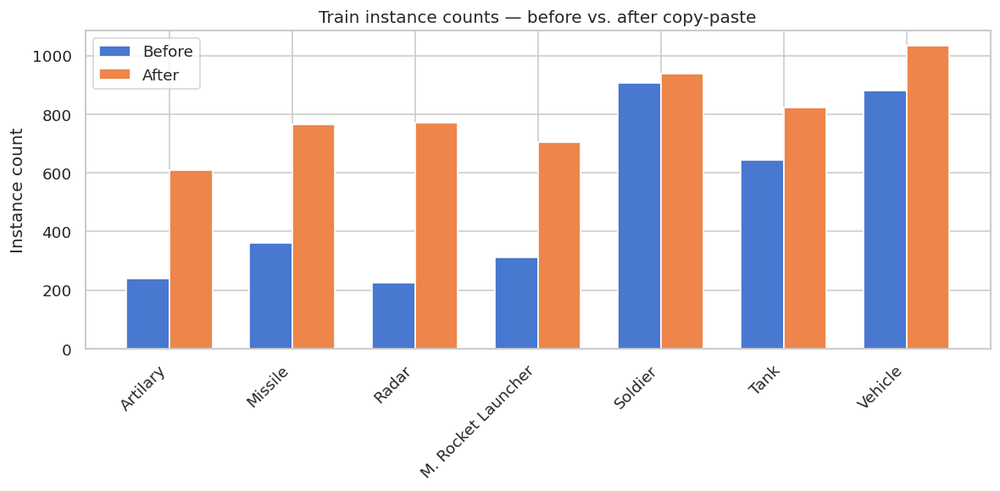

In [18]:
def count_train_instances_on_disk(lbl_dir, class_names):
    counts = Counter()
    for lbl_path in lbl_dir.glob('*.txt'):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cid = int(float(parts[0]))
                    counts[class_names[cid]] += 1
    return pd.Series(counts).reindex(class_names, fill_value=0)

after_counts = count_train_instances_on_disk(train_lbl_dir, CLASS_NAMES)
before_counts = train_instance_counts

comparison = pd.DataFrame({
    'Before': before_counts,
    'After': after_counts,
    'Added (total, incl. collateral)': after_counts - before_counts,
    'Added (target only, from log above)': pd.Series(pasted_instances_added).reindex(CLASS_NAMES, fill_value=0),
})
comparison['Collateral'] = comparison['Added (total, incl. collateral)'] - comparison['Added (target only, from log above)']
print(comparison)

before_ratio = before_counts.max() / before_counts.min()
after_ratio = after_counts.max() / after_counts.min()
print(f"\nInstance imbalance ratio — before: {before_ratio:.2f}x  ->  after: {after_ratio:.2f}x")

n_train_before = len(stems_train)
n_train_after = len(list(train_img_dir.glob('*')))
print(f"\nTrain image count — before: {n_train_before}  ->  after: {n_train_after}")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CLASS_NAMES))
width = 0.35
ax.bar(x - width/2, before_counts, width, label='Before')
ax.bar(x + width/2, after_counts, width, label='After')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylabel('Instance count')
ax.set_title('Train instance counts — before vs. after copy-paste')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Visual Spot-Check of Synthetic Images

A few copy-paste results, so quality is confirmed before trusting the instance counts above.

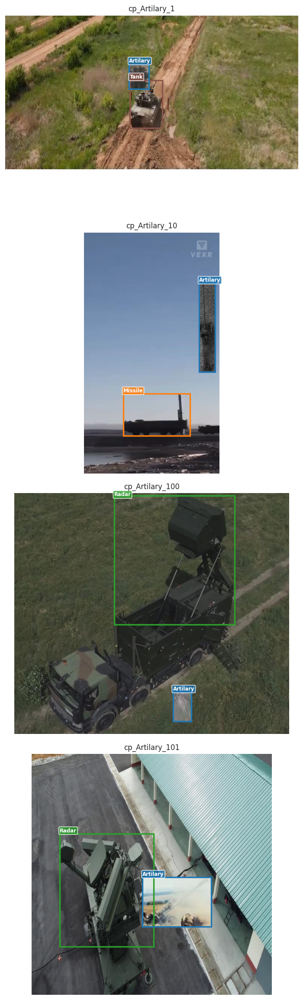

In [19]:
cp_samples = sorted(train_img_dir.glob('cp_*'))[:4]

fig, axes = plt.subplots(len(cp_samples), 1, figsize=(6, 5 * len(cp_samples)))
if len(cp_samples) == 1:
    axes = [axes]

for row, cp_path in enumerate(cp_samples):
    lbl_path = train_lbl_dir / f"{cp_path.stem}.txt"
    img, bboxes, class_labels = load_image_and_labels(cp_path, lbl_path)
    draw_boxes(img, bboxes, class_labels, CLASS_NAMES, axes[row], title=cp_path.stem)

plt.tight_layout()
plt.show()


In [20]:
# ==================== IMAGE COUNT & SPLIT RATIO — AFTER TRAIN BOOST ====================

train_dir = RESPLIT_ROOT / 'train' / 'images'
val_dir   = RESPLIT_ROOT / 'val'   / 'images'
test_dir  = RESPLIT_ROOT / 'test'  / 'images'

n_train = len(list(train_dir.glob('*')))
n_val   = len(list(val_dir.glob('*')))
n_test  = len(list(test_dir.glob('*')))
n_total = n_train + n_val + n_test

print("=" * 55)
print("IMAGE COUNT & SPLIT RATIO — POST COPY-PASTE AUGMENTATION")
print("=" * 55)
print(f"{'Split':<8} {'Images':>8} {'Share':>8}")
print("-" * 55)
print(f"{'Train':<8} {n_train:>8} {n_train/n_total*100:>7.1f}%")
print(f"{'Val':<8} {n_val:>8} {n_val/n_total*100:>7.1f}%")
print(f"{'Test':<8} {n_test:>8} {n_test/n_total*100:>7.1f}%")
print("-" * 55)
print(f"{'Total':<8} {n_total:>8} {'100.0%':>8}")

print(f"\nOriginal split ratio (Section 3, pre-augmentation): "
      f"{TRAIN_RATIO*100:.1f}/{VAL_RATIO*100:.1f}/{TEST_RATIO*100:.1f}")
print(f"Actual on-disk ratio (post copy-paste)            : "
      f"{n_train/n_total*100:.1f}/{n_val/n_total*100:.1f}/{n_test/n_total*100:.1f}")
print(f"\nNote: Train grew from {len(stems_train)} -> {n_train} images via copy-paste "
      f"(Section 4.1); val ({n_val}) and test ({n_test}) are the original, "
      f"unaugmented splits — this asymmetry is expected and correct, since "
      f"synthetic data must never appear outside train.")

IMAGE COUNT & SPLIT RATIO — POST COPY-PASTE AUGMENTATION
Split      Images    Share
-------------------------------------------------------
Train        2377    87.4%
Val           164     6.0%
Test          178     6.5%
-------------------------------------------------------
Total        2719   100.0%

Original split ratio (Section 3, pre-augmentation): 80.0/10.0/10.0
Actual on-disk ratio (post copy-paste)            : 87.4/6.0/6.5

Note: Train grew from 1339 -> 2377 images via copy-paste (Section 4.1); val (164) and test (178) are the original, unaugmented splits — this asymmetry is expected and correct, since synthetic data must never appear outside train.


In [21]:
# DATASET SIZE: BEFORE vs. AFTER AUGMENTATION

print("=" * 60)
print("DATASET SIZE — BEFORE vs. AFTER AUGMENTATION")
print("=" * 60)

n_train = len(list((RESPLIT_ROOT / 'train' / 'images').glob('*')))
n_val   = len(stems_val)
n_test  = len(stems_test)
n_total = n_train + n_val + n_test

print(f"  Train images (on disk)      : {n_train}")
print(f"  Val images (on disk)        : {n_val}")
print(f"  Test images (on disk)       : {n_test}")
print(f"  Total images (on disk)      : {n_total}")

print(f"\n  Augmentation strategy       : on-the-fly (Albumentations), not pre-generated")
print(f"  Train images per epoch      : {n_train}  (same count, re-augmented each epoch)")
print(f"  Val/Test images per epoch   : {n_val} / {n_test}  (resize-only, no augmentation)")

N_EPOCHS_EXAMPLE = 50
effective_views = n_train * N_EPOCHS_EXAMPLE
print(f"\n  Example: over {N_EPOCHS_EXAMPLE} epochs, the model sees ~{effective_views:,} "
      f"augmented image *views*")
print(f"  (still only {n_train} unique source files — no new files are written to disk)")

print("\n Augmentation increases training *diversity*, not the on-disk image count.")


DATASET SIZE — BEFORE vs. AFTER AUGMENTATION
  Train images (on disk)      : 2377
  Val images (on disk)        : 164
  Test images (on disk)       : 178
  Total images (on disk)      : 2719

  Augmentation strategy       : on-the-fly (Albumentations), not pre-generated
  Train images per epoch      : 2377  (same count, re-augmented each epoch)
  Val/Test images per epoch   : 164 / 178  (resize-only, no augmentation)

  Example: over 50 epochs, the model sees ~118,850 augmented image *views*
  (still only 2377 unique source files — no new files are written to disk)

 Augmentation increases training *diversity*, not the on-disk image count.


---
## 5. Input Pipeline Verification (Before/After Visualization)

### 5.1 Before/After Augmentation Visualisation

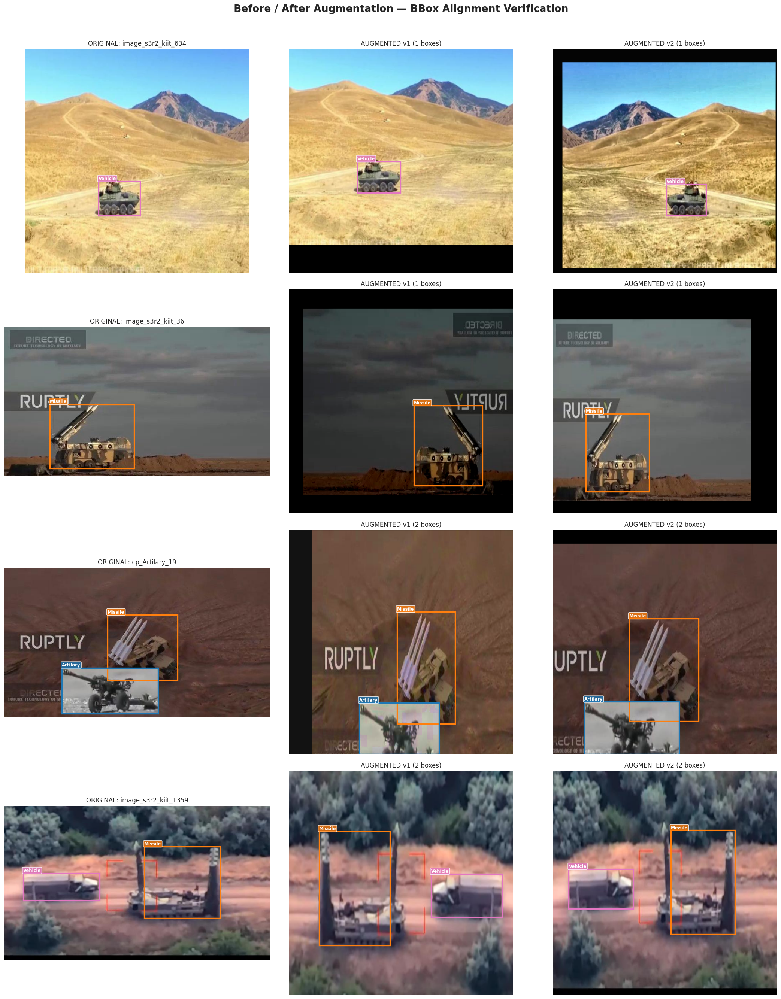

 Bounding boxes remain correctly aligned after augmentation.
   Visual inspection confirms no flipped boxes, coordinate errors, or class-index mismatches.


In [22]:
# BEFORE/AFTER AUGMENTATION VISUALISATION
def load_image_and_labels(img_path, lbl_path):
    """Load image as numpy array and parse YOLO labels."""
    img = np.array(Image.open(img_path).convert('RGB'))
    bboxes = []
    class_labels = []

    if Path(lbl_path).exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cid = int(parts[0])
                    cx, cy, w, h = map(float, parts[1:5])
                    bboxes.append([cx, cy, w, h])
                    class_labels.append(cid)

    return img, bboxes, class_labels


# Select 4 diverse sample images from the re-split training set
train_img_dir = RESPLIT_ROOT / 'train' / 'images'
train_lbl_dir = RESPLIT_ROOT / 'train' / 'labels'
train_imgs = sorted(train_img_dir.glob('*'))

np.random.seed(SEED)
sample_indices = np.random.choice(len(train_imgs), size=min(4, len(train_imgs)), replace=False)
sample_paths = [train_imgs[i] for i in sample_indices]

fig, axes = plt.subplots(4, 3, figsize=(18, 22))

for row, img_path in enumerate(sample_paths):
    stem = img_path.stem
    lbl_path = train_lbl_dir / f"{stem}.txt"

    # Load original
    img_orig, bboxes, class_labels = load_image_and_labels(img_path, lbl_path)

    # Draw original
    draw_boxes(img_orig, bboxes, class_labels, CLASS_NAMES, axes[row, 0],
               title=f"ORIGINAL: {stem}")

    # Apply augmentation (two different random augmentations)
    bboxes_clipped = clip_bbox(bboxes) if len(bboxes) > 0 else bboxes
    for aug_col in range(1, 3):
        if len(bboxes) > 0:
            augmented = train_transform(
                image=img_orig,
                bboxes=bboxes_clipped,
                class_labels=class_labels
            )
            aug_img = augmented['image']
            aug_bboxes = augmented['bboxes']
            aug_labels = augmented['class_labels']
        else:
            aug_img = cv2.resize(img_orig, (IMG_SIZE, IMG_SIZE))
            aug_bboxes, aug_labels = [], []

        draw_boxes(aug_img, aug_bboxes, aug_labels, CLASS_NAMES,
                   axes[row, aug_col],
                   title=f"AUGMENTED v{aug_col} ({len(aug_bboxes)} boxes)")

plt.suptitle('Before / After Augmentation — BBox Alignment Verification',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(" Bounding boxes remain correctly aligned after augmentation.")
print("   Visual inspection confirms no flipped boxes, coordinate errors, or class-index mismatches.")

### 5.2 Batch Verification — Augmented Batch with Ground-Truth Boxes
Plot a full batch of augmented images at the model's expected input resolution (640×640) to confirm box-to-image alignment after resizing.

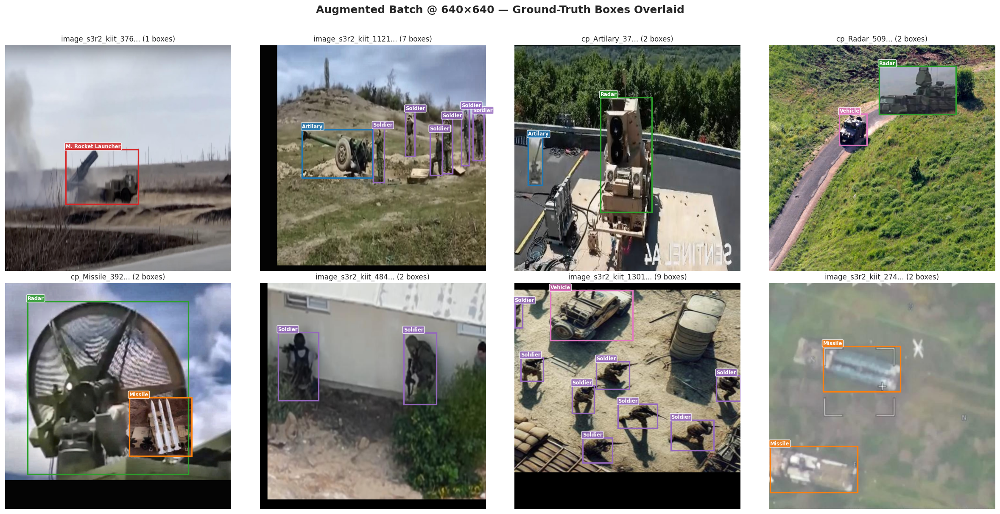

 All bounding boxes are within valid [0,1] range after augmentation and resize.
 Box-to-image alignment confirmed at model input resolution.


In [23]:
# BATCH VERIFICATION
batch_size = 8
np.random.seed(SEED + 1)
batch_indices = np.random.choice(len(train_imgs), size=min(batch_size, len(train_imgs)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

alignment_ok = True

for i, idx in enumerate(batch_indices):
    img_path = train_imgs[idx]
    stem = img_path.stem
    lbl_path = train_lbl_dir / f"{stem}.txt"

    img, bboxes, class_labels = load_image_and_labels(img_path, lbl_path)

    if len(bboxes) > 0:
        augmented = train_transform(
            image=img,
            bboxes=clip_bbox(bboxes),
            class_labels=class_labels
        )
        aug_img = augmented['image']
        aug_bboxes = augmented['bboxes']
        aug_labels = augmented['class_labels']

        # Sanity check: all coords in [0, 1]
        for bb in aug_bboxes:
            cx, cy, w, h = bb
            if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                alignment_ok = False
                print(f"  Out-of-range bbox in {stem}: {bb}")
    else:
        aug_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        aug_bboxes, aug_labels = [], []

    draw_boxes(aug_img, aug_bboxes, aug_labels, CLASS_NAMES,
               axes[i], title=f"{stem[:25]}... ({len(aug_bboxes)} boxes)")

plt.suptitle(f'Augmented Batch @ {IMG_SIZE}×{IMG_SIZE} — Ground-Truth Boxes Overlaid',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

if alignment_ok:
    print(" All bounding boxes are within valid [0,1] range after augmentation and resize.")
    print(" Box-to-image alignment confirmed at model input resolution.")
else:
    print(" Some boxes are out of range! Investigate and fix before training.")

### 5.3 Coordinate Validation — Systematic Check
Programmatically verify all augmented boxes across a larger sample to catch any edge-case failures beyond visual inspection.

In [24]:
# SYSTEMATIC COORDINATE VALIDATION
def validate_augmentation_batch(img_dir, lbl_dir, transform, n_samples=100, n_repeats=3):
    """Run augmentation on a batch and check for coordinate errors."""
    imgs = sorted(img_dir.glob('*'))
    np.random.seed(SEED)
    sample_paths = [imgs[i] for i in np.random.choice(len(imgs), min(n_samples, len(imgs)), replace=False)]

    errors = []
    total_checks = 0
    flipped_boxes = 0
    class_mismatches = 0

    for img_path in tqdm(sample_paths, desc='Validating augmentations'):
        stem = img_path.stem
        lbl_path = lbl_dir / f"{stem}.txt"
        img, bboxes, class_labels = load_image_and_labels(img_path, lbl_path)

        if len(bboxes) == 0:
            continue

        bboxes_clipped = clip_bbox(bboxes)

        for _ in range(n_repeats):
            total_checks += 1
            try:
                augmented = transform(
                    image=img,
                    bboxes=bboxes_clipped,
                    class_labels=class_labels
                )

                for bb in augmented['bboxes']:
                    cx, cy, w, h = bb
                    if not (0 <= cx <= 1 and 0 <= cy <= 1 and w > 0 and h > 0):
                        errors.append((stem, 'out_of_range', bb))
                    if w < 0 or h < 0:
                        flipped_boxes += 1

                for cl in augmented['class_labels']:
                    if cl < 0 or cl >= NUM_CLASSES:
                        class_mismatches += 1

            except Exception as e:
                errors.append((stem, 'exception', str(e)))

    return total_checks, errors, flipped_boxes, class_mismatches

n_checks, errors, flipped, cls_err = validate_augmentation_batch(
    train_img_dir, train_lbl_dir, train_transform,
    n_samples=100, n_repeats=3
)

print(f"\n{'='*50}")
print(f"AUGMENTATION VALIDATION REPORT")
print(f"{'='*50}")
print(f"Total augmentation runs : {n_checks}")
print(f"Coordinate errors       : {len(errors)}")
print(f"Flipped/negative boxes  : {flipped}")
print(f"Class-index mismatches  : {cls_err}")

if len(errors) == 0 and flipped == 0 and cls_err == 0:
    print("\n ALL CHECKS PASSED.")
    print("   No flipped boxes, coordinate errors, or class-index mismatches detected.")
    print("   The augmentation pipeline is safe for training.")
else:
    print("\n ISSUES FOUND:")
    for e in errors[:10]:
        print(f"  {e}")

Validating augmentations:   0%|          | 0/100 [00:00<?, ?it/s]


AUGMENTATION VALIDATION REPORT
Total augmentation runs : 300
Coordinate errors       : 0
Flipped/negative boxes  : 0
Class-index mismatches  : 0

 ALL CHECKS PASSED.
   No flipped boxes, coordinate errors, or class-index mismatches detected.
   The augmentation pipeline is safe for training.


---
## 6. Dataset Summary & Modeling Implications

### Leakage Prevention
19 exact duplicates (MD5) and 89 near-duplicate groups (pHash, full pairwise comparison) were found, several crossing the original train/valid/test split. All were resolved before the final leakage-safe stratified split (79.7/9.8/10.6%, near-duplicate groups kept together).

Class Imbalance
Instance-level imbalance was 4.03x before correction. EDA (Section 2.2) flagged three classes as minority by visual inspection of the distribution Artilary, Radar, M. Rocket Launcher. The correction step, however, applies a numeric threshold (60% of the majority class's instance count = 544) to every class rather than relying on that manual list, and this also caught Missile (362 instances, below threshold) so four classes received copy-paste augmentation in total, not three. Whole-image oversampling was tried first but inflates co-occurring classes as a side effect (duplicating an image duplicates every label in it). Copy-paste augmentation was used instead: crops of under-target classes are pasted onto low-content receiver images, closing each class's instance deficit toward the 544 target with far less collateral duplication of already-adequate classes (e.g. Soldier +30 vs. +296 under the whole-image method). Final instance imbalance ratio: 1.69x. Train split only, applied after the split, so no leakage risk.

### Key Dataset Characteristics

| Property | Observation | Impact on Training |
|---|---|---|
| Dataset size | ~1,700 images (moderate) | Pre-trained weights + augmentation needed to avoid overfitting |
| Object sizes | Small 11.0%, Medium 41.1%, Large 48.0% | Multi-scale detection matters (YOLO's FPN/PAN handles this) |
| Drone imagery | Aerial, canonical top-down orientation | Rotation augmentation empirically hurts mAP (Notebook 2 finding) — excluded; scale/shift and mosaic (YOLO built-in) still help sparse scenes |
| Annotation quality | 1:1 image-label match, no corrupt/missing/orphan files | No cleanup needed beyond leakage removal |

### Recommendations for training
1. Use the small (`-s`) YOLO variant — balances accuracy with Kaggle T4 constraints.
2. 640x640 input, consistent with this notebook's EDA and augmentation design.
3. Early stopping on validation mAP@50 (10-15 epoch patience).
4. Class imbalance is now primarily addressed at the data level (copy-paste above); any training-time loss weighting should be treated as a secondary, complementary lever.

---
*End of Notebook 1 - Dataset Exploration & Preprocessing*